<a href="https://colab.research.google.com/github/Gilleswint-s1128612/explainable-ai/blob/master/Final_Assignment_Explainable_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# I work in colab so we need to have a place to get the data
from google.colab import drive
import os
drive.mount('/content/drive')

path = '/content/drive/MyDrive'
os.chdir(path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# check if dice-ml still has to be installed
!pip install dice-ml
import sklearn
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import shap
import dice_ml


In [4]:
data = pd.read_csv('data/loan_data.csv')

target_var='loan_status'

# these are the columns that don't contain values, but rather text
categorical_features= ['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']

continuous_features= ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'cb_person_cred_hist_length', 'credit_score']

preprocessor = ColumnTransformer(
    transformers=[
        # necessary for dice, to make distance fair for all continuous features
        ('num', StandardScaler(), continuous_features),
        # apply oneHot encoder to make text binary numbers
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])
# rf needs only numbers, but dice needs specific names, to give the counterfactual
# thus pipeline acts as translator between these 2
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42)) # we use class_weight balanced, to counteract the class imbalance
])
# remove target var
X=data.drop(columns=[target_var])
y=data[target_var]
# create 80/20 train test split
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
# approx 77% rejected, 23% accepted thus imbalanced
print(data['loan_status'].value_counts())

loan_status
0    35000
1    10000
Name: count, dtype: int64


In [13]:
rf_pipeline.fit(X_train, y_train)
y_pred = rf_pipeline.predict(X_test)
# predictions for approval are worse then for denial
print(classification_report(y_test, y_pred))
# female = 0 blue values, male = 1 red values
print(preprocessor.named_transformers_['cat'].get_feature_names_out())

              precision    recall  f1-score   support

           0       0.94      0.96      0.95      6990
           1       0.86      0.77      0.81      2010

    accuracy                           0.92      9000
   macro avg       0.90      0.87      0.88      9000
weighted avg       0.92      0.92      0.92      9000

['person_gender_female' 'person_gender_male' 'person_education_Associate'
 'person_education_Bachelor' 'person_education_Doctorate'
 'person_education_High School' 'person_education_Master'
 'person_home_ownership_MORTGAGE' 'person_home_ownership_OTHER'
 'person_home_ownership_OWN' 'person_home_ownership_RENT'
 'loan_intent_DEBTCONSOLIDATION' 'loan_intent_EDUCATION'
 'loan_intent_HOMEIMPROVEMENT' 'loan_intent_MEDICAL'
 'loan_intent_PERSONAL' 'loan_intent_VENTURE'
 'previous_loan_defaults_on_file_No' 'previous_loan_defaults_on_file_Yes']


In [7]:
# for rf we need all numbers, no discrete strings
X_test_preprocessed= preprocessor.transform(X_test)
# link the column headers to the preprocessed data
cat_feature_names= preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
# now add all headers together again
all_feature_names= list(cat_feature_names) + continuous_features

# create a df that links preprocssed data with column again
X_test_df = pd.DataFrame(X_test_preprocessed, columns=all_feature_names)

# we take subset of 1000 data points, it otherwise took hours to run
X_shap_sample = X_test_df.sample(n=1000, random_state=42)

# fit the pretrained rf from pipeline
rf_fit = rf_pipeline.named_steps['classifier']

# use tree explainer because made for trees and we made sure all features can be split be trees
# also way faster
explainer = shap.TreeExplainer(rf_fit)
shap_values = explainer(X_shap_sample)


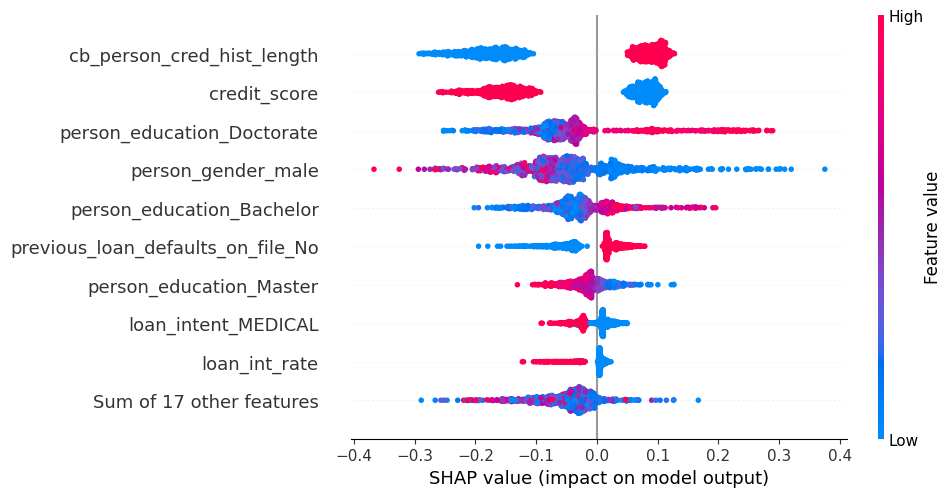

In [8]:
# need to select one of the 2 classes otherwise they cancel out
class_1_explanation = shap_values[:, :, 1]

plt.figure(figsize=(10, 6))
shap.plots.beeswarm(class_1_explanation, show=True)

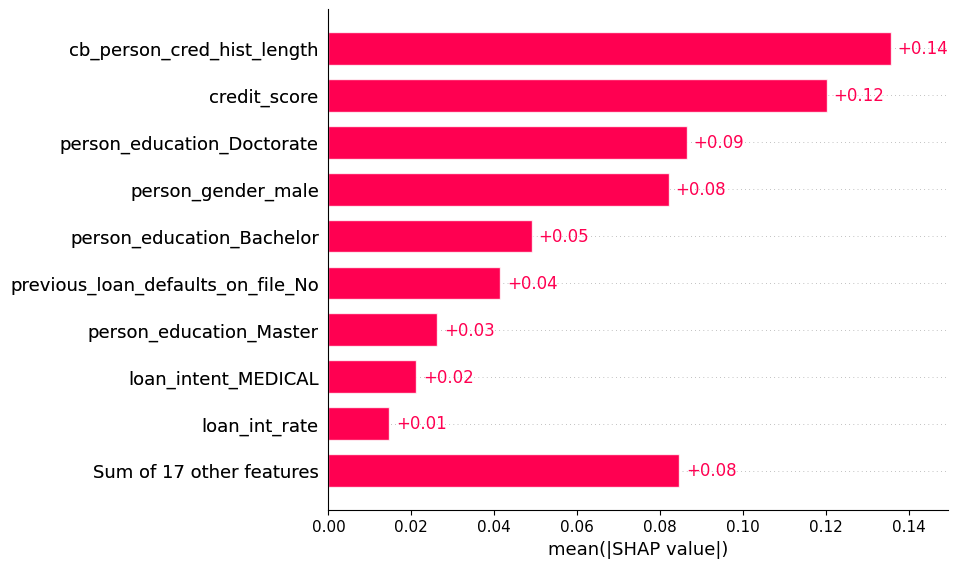

In [9]:
plt.figure(figsize=(10, 6))
shap.plots.bar(class_1_explanation, show=True)

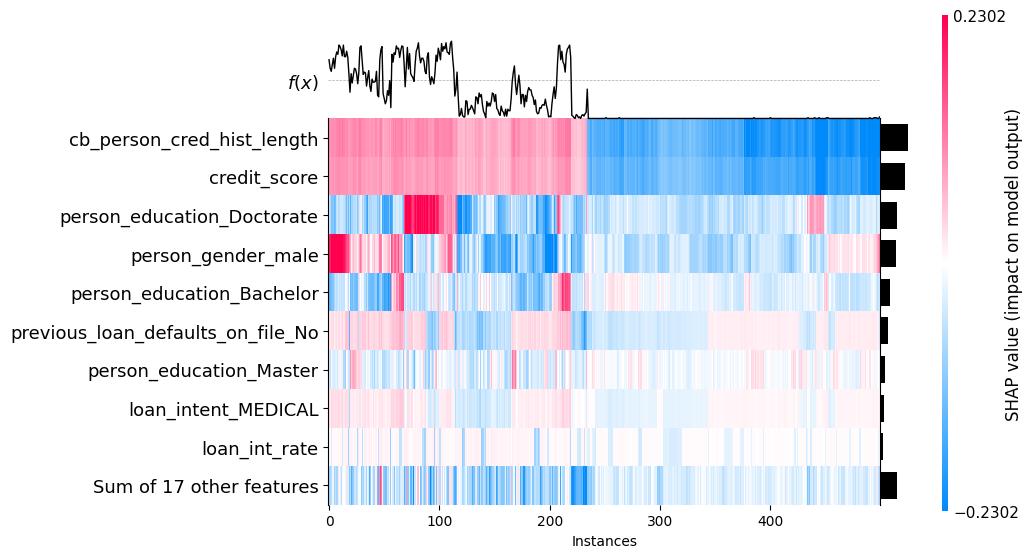

<Axes: xlabel='Instances'>

In [10]:

plt.figure(figsize=(12, 8))
shap.plots.heatmap(class_1_explanation, show=True)

In [11]:

# setup the data
train_set = X_train.copy()
train_set[target_var] = y_train

dice_data = dice_ml.Data(
    dataframe=train_set,
    continuous_features=continuous_features,
    outcome_name=target_var
)
# setup model
dice_model = dice_ml.Model(model=rf_pipeline, backend="sklearn")
# create explainer
dice_explainer = dice_ml.Dice(dice_data, dice_model, method="random")

In [12]:
#find all rejected loan applicants
rejected_test_df = X_test[y_test == 0]


# take 1000 rejected
audit_instances = rejected_test_df.sample(n=1000, random_state=42)

# I selected these variables as ones that generally could contain bias
bias_var = ['person_gender', 'person_age', 'person_education']
gender_bias_count = 0
age_bias_count = 0
education_bias_count = 0

# loop over subset of rejected applicants, and try to find counterfactual for each of the three bias var
# first loop gender
for i in range(1000):
    single_instance = audit_instances.iloc[i:i+1]
    try:
        dice_cf = dice_explainer.generate_counterfactuals(
            single_instance,
            total_CFs=1,
            desired_class="opposite",
            features_to_vary=['person_gender'] # Only gender can change
        )
        if dice_cf.cf_examples_list[0].final_cfs_df is not None:
            gender_bias_count += 1
    except:
        pass

# second loop age
for i in range(1000):
    single_instance = audit_instances.iloc[i:i+1]
    try:
        dice_cf = dice_explainer.generate_counterfactuals(
            single_instance,
            total_CFs=1,
            desired_class="opposite",
            features_to_vary=['person_age'] # Only age can change
        )
        # if there is a counterfactual found we add bias counter
        if dice_cf.cf_examples_list[0].final_cfs_df is not None:
            age_bias_count += 1
    except:
        pass

# third loop education
for i in range(1000):
    single_instance = audit_instances.iloc[i:i+1]
    try:
        dice_cf = dice_explainer.generate_counterfactuals(
            single_instance,
            total_CFs=1,
            desired_class="opposite",
            features_to_vary=['person_education'] # Only education can change
        )
        # if there is a counterfactual found we add bias counter
        if dice_cf.cf_examples_list[0].final_cfs_df is not None:
            education_bias_count += 1
    except:
        pass

print(f"Total Gender Bias found: {gender_bias_count}")
print(f"Total Age Bias found: {age_bias_count}")
print(f"Total Education Bias found: {education_bias_count}")

100%|██████████| 1/1 [00:00<00:00, 13.44it/s]


No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec


100%|██████████| 1/1 [00:00<00:00, 14.74it/s]


No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec


100%|██████████| 1/1 [00:00<00:00, 14.54it/s]


...

No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec


100%|██████████| 1/1 [00:00<00:00,  9.15it/s]


No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec


100%|██████████| 1/1 [00:00<00:00,  9.50it/s]

No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec
Total Gender Bias found: 6
Total Age Bias found: 17
Total Education Bias found: 14
